# Cassava Leaf Disease Classification using EfficientNetB3

## 📖 Introduction

**Cassava** is a critical staple crop for millions of people in Africa, Asia, and Latin America, providing a vital source of calories. However, its cultivation is severely threatened by various viral diseases, which can lead to significant yield losses and jeopardize food security. Accurate and early detection of these diseases is crucial for effective management and control.

This notebook tackles the **Cassava Leaf Disease Classification** challenge. The primary goal is to develop a machine learning model capable of accurately identifying the type of disease present on a cassava plant, or classifying it as healthy, based on an image of its leaf.

### 🌿 The Diseases
The dataset focuses on the following five categories:
1.  **Cassava Bacterial Blight (CBB)**
2.  **Cassava Brown Streak Disease (CBSD)**
3.  **Cassava Green Mottle (CGM)**
4.  **Cassava Mosaic Disease (CMD)**
5.  **Healthy**

### 🎯 Our Approach
We will employ a powerful deep learning technique called **transfer learning**. Specifically, we will fine-tune a pre-trained **EfficientNetB3** model, a state-of-the-art convolutional neural network (CNN), on the cassava leaf dataset. To accelerate the training process, we'll leverage Google's Tensor Processing Units (TPUs). The workflow includes:

- **Setting up the Environment**: Configuring the TPU strategy for distributed training.
- **Data Preprocessing**: Creating an efficient data pipeline using TFRecords.
- **Data Augmentation**: Applying various image transformations to enhance model robustness and prevent overfitting.
- **Model Building**: Constructing a custom classifier on top of the EfficientNetB3 base.
- **Two-Phase Training**: 
    1. Training only the classifier head.
    2. Fine-tuning the entire model with a low learning rate.
- **Inference**: Generating predictions on the test set.

## 🛠️ 1. Initial Setup and Imports

Let's begin by importing the essential libraries for our project. We'll need `numpy` and `pandas` for data manipulation, `tensorflow` for building and training our deep learning model, `cv2` and `matplotlib` for image processing and visualization, and `os` and `json` for file handling.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cassava-leaf-disease-classification/test_tfrecords/ld_test00-1.tfrec


/kaggle/input/cassava-leaf-disease-classification/train_images/1235188286.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1215607589.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/478554372.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2763304605.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2826122413.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/111117998.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/231268038.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4201965605.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3224710052.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1290729293.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1578977008.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2530575673.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/7202

/kaggle/input/cassava-leaf-disease-classification/train_images/1598690693.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2747090144.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2760970275.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3811519582.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4022798796.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1163169626.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/489369440.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3207676164.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4260532551.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3481763546.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2169173551.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3818159518.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/12

/kaggle/input/cassava-leaf-disease-classification/train_images/1431052836.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1427289885.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3234532653.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3540765435.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3504674817.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2671737105.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/504400425.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/838106879.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3299267468.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/967603965.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3346048761.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3674636373.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4067


/kaggle/input/cassava-leaf-disease-classification/train_images/1383148057.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1881994461.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2521993035.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/296732943.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4082694328.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/817893600.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3909057891.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2393699847.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1422781530.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3987528887.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1876635789.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/908540232.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/188


/kaggle/input/cassava-leaf-disease-classification/train_images/3376371946.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1550490538.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2967030825.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1041923025.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/431956415.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/863550761.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2977168485.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/436868168.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/295042633.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1991065222.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3956550570.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3626224621.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2697


/kaggle/input/cassava-leaf-disease-classification/train_images/622386644.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/4107720653.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1532615848.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/81845086.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/706806140.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1197223849.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/3791195339.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2487571840.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1042521522.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2359114639.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1154243459.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/1550131198.jpg
/kaggle/input/cassava-leaf-disease-classification/train_images/2887

/kaggle/input/cassava-leaf-disease-classification/test_images/2216849948.jpg


In [2]:
import os
import numpy as np
import random
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import json
import seaborn as sns
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

E0000 00:00:1755369045.862420      74 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


## 🌱 2. Ensuring Reproducibility

To make our experiments reproducible, it's crucial to set a global seed. This ensures that any process involving randomness—such as weight initialization, data shuffling, and augmentation—produces the same results every time the code is run. The function below sets the seed for Python's `random` module, `NumPy`, and `TensorFlow`.

In [3]:
def seed_everthing(SEED=28):
    # Set the Python's random module seed
    random.seed(SEED)
    
    # Set the NumPy random seed
    np.random.seed(SEED)
    
    # Set the TensorFlow random seed
    tf.random.set_seed(SEED)

    print(f"Global seed set to {SEED} 🌱")

In [4]:
seed_everthing()

Global seed set to 28 🌱


## 🚀 3. Hardware Accelerator Configuration

Training deep learning models can be computationally intensive. To speed up this process, we'll use a hardware accelerator like a TPU (Tensor Processing Unit) or GPU (Graphics Processing Unit). The following code detects the available hardware and sets up the appropriate TensorFlow distribution strategy. 

- **TPUStrategy**: For training on TPUs.
- **MirroredStrategy**: For training on multiple GPUs on a single machine.
- **Default Strategy**: For training on a single GPU or CPU.

The number of `REPLICAS` indicates how many parallel processing units are available, which is essential for scaling our batch size and distributing the training workload.

In [5]:
print("Available devices:")
for device in tf.config.list_logical_devices():
    print(device.name, device.device_type)

Available devices:
/device:CPU:0 CPU
/device:TPU:0 TPU
/device:TPU:1 TPU
/device:TPU:2 TPU
/device:TPU:3 TPU
/device:TPU:4 TPU
/device:TPU:5 TPU
/device:TPU:6 TPU
/device:TPU:7 TPU
/device:TPU_SYSTEM:0 TPU_SYSTEM


I0000 00:00:1755369068.300698      74 service.cc:148] XLA service 0x5c6b8ae09110 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755369068.300741      74 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1755369068.300746      74 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1755369068.300749      74 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1755369068.300753      74 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1755369068.300756      74 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1755369068.300759      74 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1755369068.300762      74 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1755369068.300764      74 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


In [6]:
def get_strategy():
    """
    Detects and returns the best TensorFlow distribution strategy:
    - TPU if available
    - MirroredStrategy for GPU(s)
    - Default strategy for CPU
    """
    try:
        # Try to detect a TPU
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu= 'local')  # auto-detects TPU
        print("Running on TPU:", tpu.master())
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print("Using TPU strategy:", type(strategy).__name__)
    except (ValueError, tf.errors.NotFoundError):
        try:
            # If TPU is not found, try GPU
            physical_devices = tf.config.list_physical_devices('GPU')
            if physical_devices:
                strategy = tf.distribute.MirroredStrategy()
                print("Using GPU strategy:", type(strategy).__name__)
            else:
                strategy = tf.distribute.get_strategy()  # default CPU
                print("No TPU/GPU found. Using default strategy:", type(strategy).__name__)
        except Exception as e:
            print("Failed to initialize GPU strategy:", e)
            strategy = tf.distribute.get_strategy()
            print("Using fallback strategy:", type(strategy).__name__)

    print("REPLICAS:", strategy.num_replicas_in_sync)
    return strategy


# Call this function once at the beginning of your script
strategy = get_strategy()


Running on TPU: 
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.


INFO:tensorflow:Initializing the TPU system: local


INFO:tensorflow:Finished initializing TPU system.


INFO:tensorflow:Found TPU system:


INFO:tensorflow:*** Num TPU Cores: 8


...

INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:6, TPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:7, TPU, 0, 0)


INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU_SYSTEM:0, TPU_SYSTEM, 0, 0)


Using TPU strategy: TPUStrategyV2
REPLICAS: 8


In [7]:
print("REPLICAS:", strategy.num_replicas_in_sync)
print("TensorFlow version:", tf.__version__)

REPLICAS: 8
TensorFlow version: 2.18.0


## ⚡ 4. Mixed Precision Training

To further optimize our training process, we'll enable mixed precision. This technique uses a combination of 16-bit and 32-bit floating-point types during training. It can significantly speed up computations and reduce memory usage, especially on modern GPUs and TPUs, without a substantial loss in model accuracy.

In [8]:
# List all physical devices labeled as 'GPU'
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU detected: {gpus}")
    mixed_precision.set_global_policy('mixed_float16')
else:
    print("❌ No GPU found. Using CPU instead.")


❌ No GPU found. Using CPU instead.


## 📂 5. Data Loading and Exploration

Now, let's define the paths to our data files. We need the directory containing the training images, the CSV file with image labels, and the JSON file that maps numerical labels to their corresponding disease names.

In [9]:
DATA_DIR = '/kaggle/input/cassava-leaf-disease-classification'
TRAIN_DIR = os.path.join(DATA_DIR, 'train_images')
CSV_PATH = os.path.join(DATA_DIR, 'train.csv')
LABEL_PATH = os.path.join(DATA_DIR, 'label_num_to_disease_map.json')

In [10]:
# Let's have a look at some of the image file names
print(os.listdir(TRAIN_DIR)[:5])

['1235188286.jpg', '1215607589.jpg', '478554372.jpg', '2763304605.jpg', '2826122413.jpg']


In [11]:
# Read one image to check its dimensions
img_files = os.listdir(TRAIN_DIR)
img_path = os.path.join(TRAIN_DIR, img_files[0])
img = cv2.imread(img_path)
print(img.shape)

(600, 800, 3)


In [12]:
# Load the label-to-disease name mapping from the JSON file
with open(LABEL_PATH, 'r') as f:
    label_map = json.load(f)

### Loading the Training DataFrame
We load the `train.csv` file into a pandas DataFrame. This file contains the `image_id` and its corresponding `label`. We'll convert the labels to string type for easier handling.

In [13]:
df = pd.read_csv(CSV_PATH)
# Convert the 'label' column to string type for consistency
df['label'] = df['label'].astype(str)
print(df.tail())
print(df.shape)

            image_id label
21392  999068805.jpg     3
21393  999329392.jpg     3
21394  999474432.jpg     1
21395  999616605.jpg     4
21396  999998473.jpg     4
(21397, 2)


### Analyzing Class Distribution
Understanding the distribution of classes is a vital step in any classification problem. It helps us identify if there is a class imbalance, which can affect the model's performance. A significant imbalance might require special techniques like class weighting or over/under-sampling.

In [14]:
# Get the count of images for each class
df['label'].value_counts()

label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64

/tmp/ipykernel_74/335361291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=df["label"],palette="viridis",order=df['label'].value_counts().index)


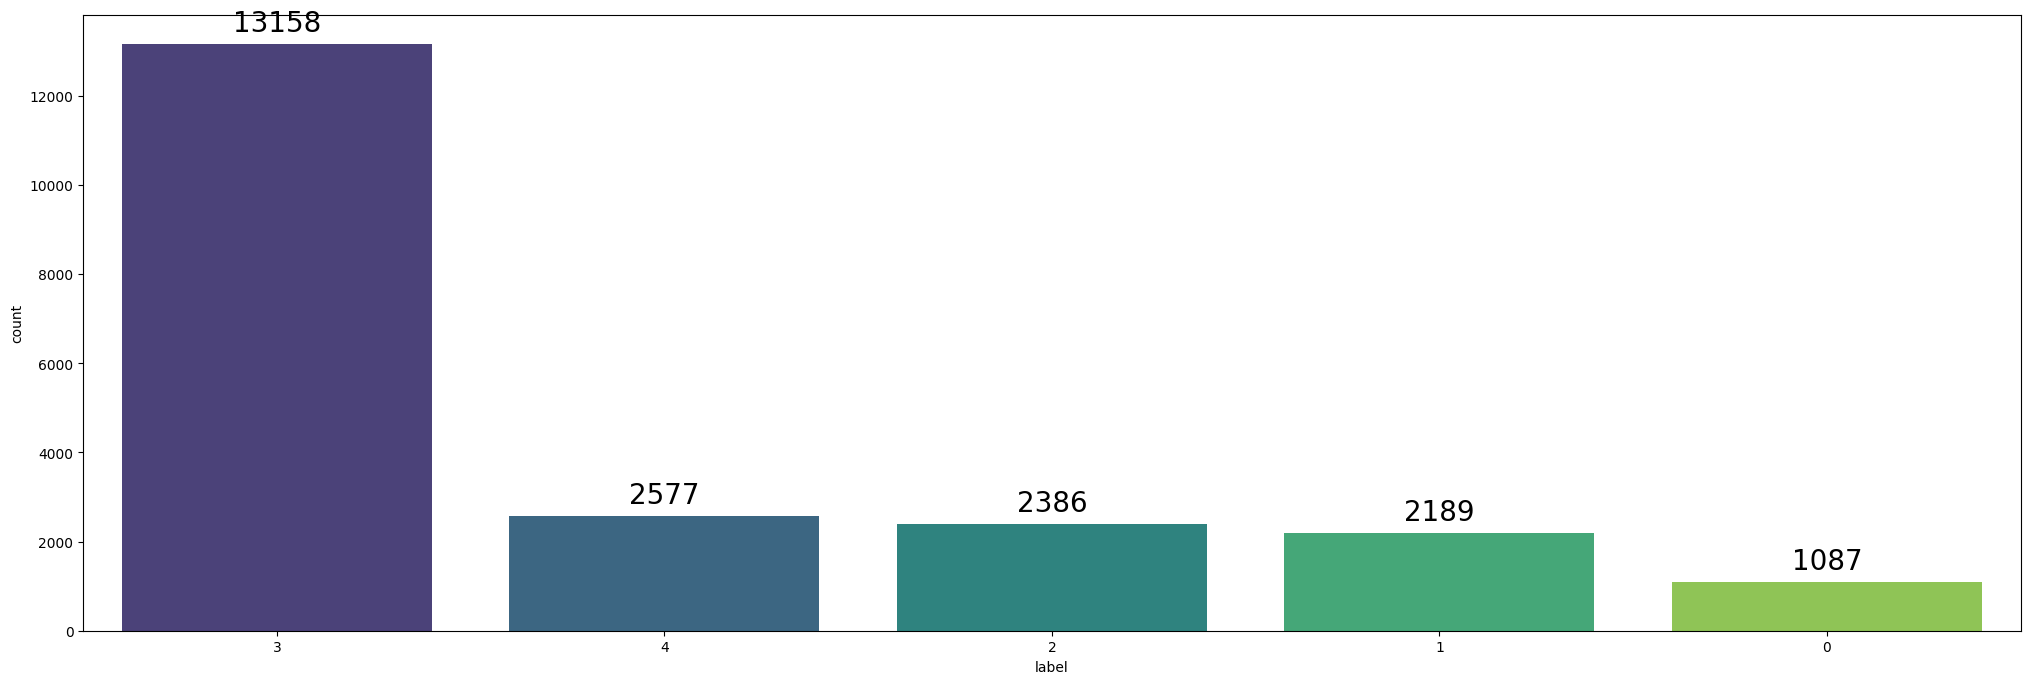

In [15]:
# Visualize the class distribution using a bar chart
plt.figure(figsize=(25,8))
ax=sns.countplot(x=df["label"],palette="viridis",order=df['label'].value_counts().index)
# Add labels on top of the bars for clarity
for p in ax.containers:
    ax.bar_label(p, fontsize=20, color='black', padding=5);

### Visualizing Sample Images
To get a better feel for the dataset, let's visualize one sample image from each of the five categories. This helps us understand the visual characteristics of healthy leaves and leaves affected by different diseases.

In [16]:
def show_images_from_each_category(df, label_map, rows= 1, images_per_class= 1):
    classes = df['label'].unique()
    num_classes = len(classes)
    columns = images_per_class
    
    plt.figure(figsize= (10* rows,10* columns))
    
    for i, c in enumerate(classes):
        # Get random samples for the current class
        class_samples = df[df['label'] == c].sample(images_per_class)
        for j ,(_, row) in enumerate(class_samples.iterrows()):
            # Construct the full image path
            img_path = os.path.join(TRAIN_DIR, row['image_id'])
            img = cv2.imread(img_path)
            # Convert image from BGR (OpenCV default) to RGB for correct display with Matplotlib
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Get the disease name from the label map
            label_name = label_map.get(row['label'], row['label'])

            # Create a subplot for each image
            plt.subplot(num_classes, columns, i* columns + j +1)
            plt.imshow(img)
            plt.title(f'{label_name}')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

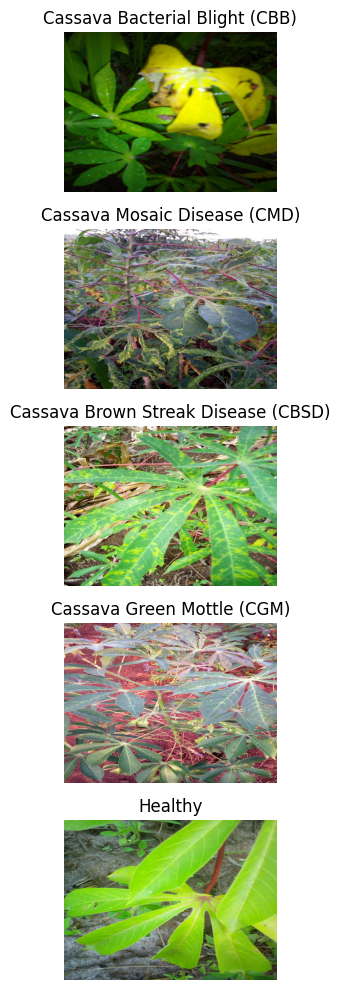

In [17]:
show_images_from_each_category(df, label_map, rows= 1, images_per_class= 1)

## ⚙️ 6. Data Pipeline with TFRecords

For efficient data handling, especially with large datasets and TPUs, we will use the **TFRecord** format. TFRecord is a binary file format that stores a sequence of protocol buffer messages, which is highly optimized for reading data in TensorFlow.

First, we'll locate the directory containing our pre-processed TFRecord files.

In [18]:
tfrecord_dir = '/kaggle/input/cassava-leaf-disease-classification/train_tfrecords'
print(os.listdir(tfrecord_dir))

['ld_train14-1338.tfrec', 'ld_train13-1338.tfrec', 'ld_train04-1338.tfrec', 'ld_train01-1338.tfrec', 'ld_train08-1338.tfrec', 'ld_train00-1338.tfrec', 'ld_train10-1338.tfrec', 'ld_train02-1338.tfrec', 'ld_train15-1327.tfrec', 'ld_train03-1338.tfrec', 'ld_train11-1338.tfrec', 'ld_train12-1338.tfrec', 'ld_train06-1338.tfrec', 'ld_train09-1338.tfrec', 'ld_train07-1338.tfrec', 'ld_train05-1338.tfrec']


### Configuration Parameters
Here, we define several key parameters for our data pipeline and model. 

- `AUTO`: An instruction for TensorFlow to automatically tune the level of parallelism for data pipeline operations.
- `IMAGE_SIZE`: The dimensions to which all images will be resized. EfficientNetB3 performs well with larger image sizes.
- `NUM_CLASSES`: The number of distinct categories in our classification task.
- `BATCH_SIZE`: The total number of samples processed in one forward/backward pass. We calculate the **global batch size** by multiplying the per-replica batch size by the number of available replicas (TPU cores or GPUs). This ensures that the model sees the same total number of images per step, regardless of the distribution strategy.

In [19]:
AUTO = tf.data.AUTOTUNE
IMAGE_SIZE = (512, 512)
BATCH_SIZE_PER_REPLICA = 8
NUM_CLASSES = 5
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync
print(f'Global Batch size: {BATCH_SIZE}')

Global Batch size: 64


### Decoding TFRecord Examples
This function is responsible for parsing a single example from a TFRecord file. It reads the raw byte strings for the image and its target label, decodes the JPEG image, resizes it to our standard `IMAGE_SIZE`, and finally, one-hot encodes the label. One-hot encoding converts the integer label (e.g., 3) into a binary vector (e.g., `[0, 0, 0, 1, 0]`), which is the required format for categorical cross-entropy loss.

In [20]:
def decode_example(example):
    # Define the structure of the features in the TFRecord file
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'target': tf.io.FixedLenFeature([], tf.int64),
    }
    # Parse the input `example` protocol buffer using the feature description
    example = tf.io.parse_single_example(example, feature_description)
    
    # Decode the JPEG-encoded image string to a tensor
    image = tf.image.decode_jpeg(example['image'], channels=3)
    # Resize the image to the desired dimensions
    image = tf.image.resize(image, IMAGE_SIZE)
    
    # Get the integer label
    label_int = example['target']
    
    # One-hot encode the label for the model
    label = tf.one_hot(label_int, NUM_CLASSES)
    
    return image, label

### Preprocessing Input for EfficientNet
Pre-trained models like EfficientNet expect their input data to be preprocessed in a specific way (e.g., pixel values scaled to a certain range). The `preprocess_input` function from `tf.keras.applications.efficientnet` handles this for us, ensuring our images are in the correct format for the model.

In [21]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess(image, label):
    # Apply the specific preprocessing required by the EfficientNet model
    image = preprocess_input(image)
    return image, label

### 🎨 Data Augmentation
Data augmentation is a powerful technique to increase the diversity of the training data without collecting new samples. By applying random transformations like rotations, flips, and zooms to the training images, we can make our model more robust and less prone to overfitting. We define a `Sequential` model that will apply these augmentations on the fly during training.

In [22]:
data_augmentation = tf.keras.Sequential([
    # Geometric Transformations
    tf.keras.layers.RandomRotation(40/ 360), # Randomly rotate images
    tf.keras.layers.RandomTranslation(0.2, 0.2), # Randomly shift images horizontally and vertically
    tf.keras.layers.RandomZoom(0.2, 0.2), # Randomly zoom into images
    tf.keras.layers.RandomFlip('horizontal'), # Randomly flip images horizontally
    tf.keras.layers.RandomFlip('vertical') # Randomly flip images vertically
], name="data_augmentation")

In [23]:
# Define the augmentation function that will be mapped to the dataset
def apply_augmentation(image, label):
    # Keras augmentation layers expect a batch of images.
    # We add a batch dimension, apply the augmentation, and then remove it.
    image = tf.expand_dims(image, 0) # Add batch dimension
    image = data_augmentation(image)
    image = tf.squeeze(image, 0)      # Remove batch dimension
    return image, label

### Assembling the Data Pipeline
This function brings everything together to create our final `tf.data.Dataset` object. It reads the TFRecord files, decodes and preprocesses the data, and applies augmentation (only to the training set). Key steps include:

- `.with_options(ignore_order)`: Disables deterministic order to improve performance.
- `.map()`: Applies our decoding, preprocessing, and augmentation functions in parallel.
- `.shuffle()`: Shuffles the training data to ensure the model doesn't learn from the order of examples.
- `.batch()`: Groups the data into batches.
- `.prefetch()`: Prepares subsequent batches while the current one is being processed, which helps to prevent data pipeline bottlenecks.

In [24]:
def load_dataset(filenames, is_training=True):
    ignore_order = tf.data.Options()
    ignore_order.experimental_deterministic = False  # for performance
    # Create a dataset from the TFRecord files
    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads= AUTO)
    # Disable deterministic order for better performance
    dataset = dataset.with_options(ignore_order)
    # Decode each example in the dataset
    dataset = dataset.map(decode_example, num_parallel_calls= AUTO)
    # Preprocess the images for the model
    dataset = dataset.map(preprocess, num_parallel_calls= AUTO)
    # Apply augmentations and shuffling only to the training set
    if is_training:
        dataset = dataset.shuffle(8196)
        dataset = dataset.map(apply_augmentation, num_parallel_calls= AUTO)
    # Batch the dataset and prefetch for performance
    dataset = dataset.batch(BATCH_SIZE, drop_remainder= True).prefetch(AUTO)
    return dataset

### Creating Training and Validation Datasets
We'll split our TFRecord files into a training set and a validation set. A common split is 80% for training and 20% for validation. The validation set is crucial for monitoring the model's performance on unseen data during training and for tuning hyperparameters.

In [25]:
# Get a list of all TFRecord files
all_files = sorted(tf.io.gfile.glob(os.path.join(tfrecord_dir, '*.tfrec')))

# Split the files into training and validation sets (e.g., 80% train, 20% val)
split_index = int(0.8 * len(all_files)) + 1
train_files = all_files[:split_index]
val_files = all_files[split_index:]

In [26]:
# Create the dataset objects using our pipeline function
train_dataset = load_dataset(train_files, is_training=True)
val_dataset = load_dataset(val_files, is_training=False)
print(f'Train and validation set created successfully!')

Train and validation set created successfully!


### Calculating Steps Per Epoch
To properly train our model, we need to know how many batches of data constitute one full epoch. We calculate `steps_per_epoch` for the training set and `validation_steps` for the validation set. This is done by counting the total number of images in each set and dividing by the global batch size.

In [27]:
# Helper function to count the total number of examples in a set of TFRecord files
def count_total_examples(tfrecord_files):
    count = 0
    for fname in tfrecord_files:
        count += sum(1 for _ in tf.data.TFRecordDataset(fname))
    return count

In [28]:
# Count the number of images in the training and validation sets
num_train_images = count_total_examples(train_files)
num_val_images = count_total_examples(val_files)

# Calculate the number of steps (batches) per epoch
steps_per_epoch = num_train_images // BATCH_SIZE
validation_steps = num_val_images // BATCH_SIZE

print(f'Batch steps on training: {steps_per_epoch}\nSteps on validation: {validation_steps}')

Batch steps on training: 271
Steps on validation: 62


### Verifying the Data Pipeline
Let's inspect a single batch from our training dataset to ensure that the images and labels have the correct shapes and data types. This is a good sanity check before starting the training process.

In [29]:
# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    # Print the shape of the image and label tensors
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    # Print an example one-hot encoded label
    print("Label example (one-hot):", labels[0].numpy())

Image batch shape: (64, 512, 512, 3)
Label batch shape: (64, 5)


Label example (one-hot): [0. 0. 0. 1. 0.]


## 🧠 7. Model Building with Transfer Learning

We will now construct our model using **transfer learning**. We'll use **EfficientNetB3**, a powerful and efficient model pre-trained on the large ImageNet dataset. The idea is to leverage the features learned by this model (like edges, textures, and shapes) and adapt them to our specific task of classifying cassava leaf diseases.

Our model architecture will consist of:
1.  **The Base Model**: The pre-trained `EfficientNetB3` with its top classification layer removed (`include_top=False`). We'll initially freeze its weights so they don't change during the first phase of training.
2.  **A Custom Classifier Head**: We will add our own layers on top of the base model:
    - `GlobalAveragePooling2D`: To flatten the feature maps from the base model.
    - `Dense` layer with `relu` activation: A hidden layer to learn more complex patterns.
    - `Dropout`: A regularization technique to prevent overfitting.
    - `Dense` output layer with `softmax` activation: To produce a probability distribution over the 5 classes.

In [30]:
from tensorflow.keras.regularizers import l2
def cassava_model(IMAGE_SIZE):
    
    # Load the EfficientNetB3 model, pre-trained on ImageNet
    base_model = tf.keras.applications.EfficientNetB3(
        weights= 'imagenet',
        include_top= False, # Do not include the final ImageNet classifier layer
        input_shape= IMAGE_SIZE + (3,)
    )
    
    # Freeze the weights of the base model. We will only train the new classifier head initially.
    base_model.trainable = False
        
    # Define the model input
    inputs = tf.keras.layers.Input(shape= IMAGE_SIZE + (3, ))
    # Pass the inputs through the base model
    eff = base_model(inputs)
    # Add our custom classifier head
    avg = tf.keras.layers.GlobalAveragePooling2D()(eff)
    fc = tf.keras.layers.Dense(256, activation= 'relu', kernel_regularizer= l2(0.001))(avg)
    dropout = tf.keras.layers.Dropout(0.3)(fc)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation= 'softmax')(dropout)
    
    # Create the final model
    model = tf.keras.Model(inputs= inputs, outputs= outputs)
    # Print a summary of the model architecture
    model.summary()

    return model

## 🏋️ 8. Training Phase 1: Training the Head

In the first phase of training, we only train the weights of the custom classifier head we added. The weights of the EfficientNetB3 base model remain frozen. This allows the new layers to learn to interpret the features extracted by the base model for our specific dataset without disrupting the valuable pre-trained knowledge.

### Callbacks
We will use several callbacks to manage the training process:
- `ModelCheckpoint`: Saves the model with the best validation loss.
- `EarlyStopping`: Stops training if the validation loss doesn't improve for a set number of epochs, preventing overfitting.
- `ReduceLROnPlateau`: Reduces the learning rate if the training plateaus, helping the model to find a better minimum.

In [31]:
# Save the best model based on validation loss
checkpoint_cb = ModelCheckpoint(
    '/kaggle/working/initial_model_cassava.keras', # File to save the best model
    monitor='val_loss',
    save_best_only=True,
    mode='min' # We want to minimize loss
)

# Stop training if validation loss doesn't improve for 3 epochs
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # This is great, it restores the weights from the best epoch
)

# Reduce learning rate when learning plateaus
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

callbacks = [checkpoint_cb, early_stopping_cb, reduce_lr_cb]

### Compiling and Fitting the Model
We compile the model within the `strategy.scope()` to ensure it's distributed across the available TPUs/GPUs. We use the `Adam` optimizer, `CategoricalCrossentropy` loss with **label smoothing** (a regularization technique that prevents the model from becoming overconfident), and track `accuracy` as our performance metric. Then, we start the training process.

In [32]:
with strategy.scope():
    # Build the model
    model = cassava_model(IMAGE_SIZE)
    # Compile the model with optimizer, loss, and metrics
    model.compile(optimizer = tf.keras.optimizers.Adam(3e-4), 
                  loss= tf.keras.losses.CategoricalCrossentropy(label_smoothing= 0.01), 
                  metrics= ['accuracy'],
                  steps_per_execution= 32 if isinstance(strategy, tf.distribute.TPUStrategy) else 1)

# Set the number of epochs for this training phase
initial_epoch = 15
print("--- Starting Phase 1: Training Head Classifier ---")
# Fit the model to the training data
history = model.fit(train_dataset.repeat(), 
                    validation_data= val_dataset.repeat(),
                    epochs= initial_epoch,
                    callbacks= callbacks,
                    steps_per_epoch= steps_per_epoch,
                    validation_steps= validation_steps)

I0000 00:00:1755369120.826858      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


       0/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/43941136 ━━━━━━━━━━━━━━━━━━━━ 1:39 2us/step

   81920/43941136 ━━━━━━━━━━━━━━━━━━━━ 1:50 3us/step

  147456/43941136 ━━━━━━━━━━━━━━━━━━━━ 1:16 2us/step

...

161/271 ━━━━━━━━━━━━━━━━━━━━ 22s 202ms/step - accuracy: 0.8109 - loss: 0.6626

193/271 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.8108 - loss: 0.6611

225/271 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.8112 - loss: 0.6594 

257/271 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.8114 - loss: 0.6581

271/271 ━━━━━━━━━━━━━━━━━━━━ 55s 191ms/step - accuracy: 0.8108 - loss: 0.6584 - val_accuracy: 0.7898 - val_loss: 0.6834 - learning_rate: 6.0000e-05


In [33]:
# Check the history object from your training run
val_loss_history = history.history['val_loss']
best_val_loss = min(val_loss_history)
best_epoch = val_loss_history.index(best_val_loss) + 1

print(f"Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch}")
print(f"Final Validation Loss: {val_loss_history[-1]:.4f} at Epoch {len(val_loss_history)}")

Lowest Validation Loss: 0.6660 at Epoch 12
Final Validation Loss: 0.6834 at Epoch 15


## 🎨 9. Training Phase 2: Fine-Tuning

After the classifier head has been trained and has converged, we can move to the fine-tuning phase. Here, we **unfreeze** the entire base model (or some of its top layers) and continue training with a **very low learning rate**. 

This allows the model to make small adjustments to the pre-trained weights, adapting them more closely to the specifics of the cassava leaf dataset. Using a low learning rate is critical to avoid destroying the valuable features learned during pre-training.

In [34]:
# Define a new set of callbacks for the fine-tuning phase
fn_checkpoint_cb = ModelCheckpoint(
    '/kaggle/working/final_model_cassava.keras', # File to save the best model
    monitor='val_loss',
    save_best_only=True,
    mode='min' # We want to minimize loss
)

# Stop training if validation loss doesn't improve for 4 epochs
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True # This is great, it restores the weights from the best epoch
)

# Reduce learning rate when learning plateaus
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

callbacks = [fn_checkpoint_cb, early_stopping_cb, reduce_lr_cb]

In [35]:
with strategy.scope():

    # Unfreeze the base model to make it trainable
    base_model = model.get_layer('efficientnetb3')
    base_model.trainable = True

    # Re-compile the model with a much lower learning rate for fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
        metrics=['accuracy'],
        steps_per_execution= 32 if isinstance(strategy, tf.distribute.TPUStrategy) else 1
    )

print("--- Starting Phase 2: Fine tune some last layers ---")
final_epochs = initial_epoch + 50
# Continue training the model
history_final = model.fit(
    train_dataset.repeat(),
    validation_data= val_dataset.repeat(),
    epochs= final_epochs,
    initial_epoch= initial_epoch, # Start from the epoch number where the first phase left off
    callbacks= callbacks,
    steps_per_epoch= steps_per_epoch,
    validation_steps= validation_steps
)

--- Starting Phase 2: Fine tune some last layers ---


Epoch 16/65


I0000 00:00:1755370259.713389      74 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:10864952721106375132


I0000 00:00:1755370279.908064     844 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(9040667502386733345), session_name()


I0000 00:00:1755370341.503221     844 tpu_compile_op_common.cc:245] Compilation of 9040667502386733345 with session name  took 1m1.595090837s and succeeded


...

161/271 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.8759 - loss: 0.4390

193/271 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8772 - loss: 0.4359

225/271 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.8791 - loss: 0.4324 

257/271 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.8804 - loss: 0.4296

271/271 ━━━━━━━━━━━━━━━━━━━━ 58s 180ms/step - accuracy: 0.8811 - loss: 0.4285 - val_accuracy: 0.8682 - val_loss: 0.4753 - learning_rate: 1.2000e-06


In [37]:
# Create the test dataset pipeline
TEST_DIR = os.path.join(DATA_DIR, 'test_tfrecords')
test_files = tf.io.gfile.glob(os.path.join(TEST_DIR, '*.tfrec'))
test_dataset = tf.data.TFRecordDataset(test_files, num_parallel_reads= AUTO)
test_dataset = (test_dataset
                .map(decode_test_example, num_parallel_calls= AUTO)
                .map(lambda image, image_id: (preprocess_input(image), image_id), num_parallel_calls= AUTO)
                .batch(BATCH_SIZE)
                .prefetch(AUTO))

print('Test dataset created Successfully !')

Test dataset created Successfully !


### Test-Time Augmentation (TTA)

To potentially improve our prediction accuracy, we will use **Test-Time Augmentation (TTA)**. This technique involves creating multiple augmented versions of each test image, making a prediction for each version, and then averaging these predictions. This process can lead to more robust and accurate results as it reduces the impact of random variations in the test images.

In [38]:
# A new function to apply augmentation to a single image during inference
def apply_test_augmentation(image):
    # Expand dims to make it a batch of 1
    image = tf.expand_dims(image, 0)
    # Apply the same data augmentation layers used in training
    image = data_augmentation(image)
    # Squeeze to remove the batch dimension
    image = tf.squeeze(image, 0)
    return image

In [39]:
# A function to get TTA predictions for a single image
def tta_predict_image(model, image, num_tta):
    # Create 'num_tta' augmented versions of the input image
    augmented_images = tf.stack([apply_test_augmentation(image) for _ in range(num_tta)])
    
    # Preprocess the augmented images for the EfficientNet model
    preprocessed_images = preprocess_input(augmented_images)
    
    # Predict on the batch of augmented images
    predictions = model.predict(preprocessed_images)
    
    # Average the predictions across all augmented versions
    mean_predictions = tf.reduce_mean(predictions, axis=0)
    
    return mean_predictions

In [40]:
# Iterate through the test dataset and generate TTA predictions for each image
tta_num_augmentations = 10  # Number of augmented images to create per test image
tta_predictions = []
tta_image_names = []

for images, ids in test_dataset:
    for i in range(images.shape[0]):
        # Get a single image and its ID from the batch
        image = images[i]
        image_name = ids[i].numpy().decode('utf-8')
        
        # Get TTA prediction for this single image
        mean_preds = tta_predict_image(model, image, tta_num_augmentations)
        
        tta_predictions.append(mean_preds)
        tta_image_names.append(image_name)

I0000 00:00:1755371443.774195      74 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:5102681950515235227


E0000 00:00:1755371444.103070      74 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node functional_1_1/dense_1/BiasAdd/ReadVariableOp.


W0000 00:00:1755371444.344340      74 loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/branch_executed/_8


I0000 00:00:1755371444.941315     900 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(14082074147753307431), session_name()


I0000 00:00:1755371456.807879     900 tpu_compile_op_common.cc:245] Compilation of 14082074147753307431 with session name  took 11.866504904s and succeeded


I0000 00:00:1755371456.826564     900 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(14082074147753307431), session_name(), subgraph_key(std::string(property.function_name) = "cluster_multi_step_on_data_5102681950515235227", property.function_library_fingerprint = 2993968918309002635, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "2,512,512,3,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1755371456.826613     900 tpu_compilation_cache_interface.cc:542] After adding entry for key 14082074147753307431 with session_name  cache is 5 entries (549825110 bytes),  marked for eviction 0 entries (0 bytes).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


In [41]:
# Convert the list of predictions to a NumPy array for final processing
tta_predictions = np.array(tta_predictions)
# Find the index of the highest probability for each prediction to get the final label
final_tta_labels = tf.argmax(tta_predictions, axis=1)
pred_labels = final_tta_labels.numpy()

# Create a dictionary for the submission DataFrame
submission_dict = {
    'image_id': tta_image_names,
    'label': pred_labels
}
# Create the submission DataFrame using pandas
submission_df = pd.DataFrame(submission_dict)
print('Submission dataframe created successfully !')
submission_df.tail()

Submission dataframe created successfully !


,image_id,label
0,2216849948.jpg,4


In [42]:
# Save the DataFrame to a CSV file without the index
submission_df.to_csv('/kaggle/working/submission.csv', index= False)
print(f'Submission CSV file created successfully!')

Submission CSV file created successfully!
